<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/kmeans_km.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries**

In [1]:
!pip install plotly
!pip install tabulate
!pip install pandas openpyxl

In [2]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px

from statsmodels.graphics.correlation import plot_corr
from scipy.stats import skew
from scipy.stats import kurtosis
import missingno as msno

#Clustering
from sklearn.preprocessing import MinMaxScaler , LabelEncoder
from sklearn.cluster import KMeans


#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate


# **Importing Data**

In [3]:
# Reading data

url = "https://raw.githubusercontent.com/kwanda2426/projects/main/airpoll_spreadsheet.xlsx"

In [4]:
df = pd.read_excel(url)


In [5]:
# Showing first 5 lines of data
df.head()


,SO2,NO2,O3,PM2.5,PM10
0,12.066771,26.209577,50.274385,30.133367,49.601856
1,9.960118,26.414410,50.725530,39.431072,63.532406
2,13.042188,28.175000,59.656341,30.048178,51.604358
3,14.110423,30.427946,45.042525,35.744039,59.892717
4,16.469369,25.970691,46.352582,22.802231,39.986833


In [6]:
#data columns
df.columns

Index(['SO2', 'NO2', 'O3', 'PM2.5', 'PM10'], dtype='object')

In [7]:
# Rows and Columns of data
print('Data has {} rows and {} Columns'.format(df.shape[0],df.shape[1]))
print('')
print('Data has the following columns:')
for i in df.columns:
  print(i)

Data has 3347 rows and 5 Columns

Data has the following columns:
SO2
NO2
O3
PM2.5
PM10


### Data Type of Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3347 entries, 0 to 3346
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SO2     3347 non-null   float64
 1   NO2     3347 non-null   float64
 2   O3      3347 non-null   float64
 3   PM2.5   3347 non-null   float64
 4   PM10    3347 non-null   float64
dtypes: float64(5)
memory usage: 130.9 KB


Data set has no missing values.

## Describing the variables

In [9]:
#describing numerical columns
df.describe()

,SO2,NO2,O3,PM2.5,PM10
count,3347.000000,3347.000000,3347.000000,3347.000000,3347.000000
mean,15.457743,30.233894,49.046178,30.840341,53.068965
std,7.958836,9.840362,13.678701,10.881794,19.495417
min,2.440214,5.313647,14.307370,7.247189,12.460333
25%,9.822467,23.342326,38.955383,23.265236,39.293278
50%,13.668863,28.622035,47.986737,29.131225,49.776500
75%,19.211052,35.268649,57.857050,36.256992,63.601911
max,63.565143,80.808551,103.912130,80.611000,131.746833


# **Exploratory Data Analysis**

This method is meant to uncover the underlying structure of a data set and is important for a company because it exposes trends, patterns, and relationships that are not readily apparent.


**Correlation**

This is meant to discover :

    Relationship between features and target variable.
    Multicollinearity - where features are highly correlated to each other. This guides whether to combine features or not as this means that features carry the same information.
    Most informative features. This helps to (simplify the model, reduce noise and improve predictive accuracy) by focusing on informative features only.
    Patterns such as if one feature increases, so does another OR One decreases , the other increases.
    +1 shows a strong positive correlation and -1 shows a strong negative correlation.



In [11]:


# Compute correlation matrix
df_corr = df.copy()
corr_matrix = df_corr.corr(numeric_only=True)

# Create heatmap
fig = px.imshow(
    corr_matrix,
    text_auto = True,
    color_continuous_scale = 'RdBu',
    zmin = -1, zmax = 1,
    title = 'Feature Correlation Heatmap'
)

fig.update_layout(
    width=800,
    height=600,
    margin=dict(l=50, r=50, t=50, b=50)
)

fig.show()




Overview of Relationships
This heatmap offers a compelling snapshot of how various air pollutants interact with one another. The Pearson correlation coefficients reveal both synergistic and antagonistic relationships, which can be crucial for environmental monitoring and policy-making.

🔗 Strong Positive Correlations
- PM₂.₅ & PM₁₀ (0.87)
This is the most striking relationship in the matrix. These two particulate matter types are often emitted from similar sources—like vehicle exhaust, industrial processes, and biomass burning—so their strong correlation suggests they tend to rise and fall together. This could simplify monitoring efforts: tracking one may give insight into the other.
- NO₂ & PM₂.₅ (0.67) and NO₂ & PM₁₀ (0.64)
These moderate-to-strong correlations indicate that nitrogen dioxide, a common traffic-related pollutant, is often accompanied by elevated particulate levels. Urban areas with heavy traffic might show this pattern consistently.
- SO₂ & NO₂ (0.51)
This moderate correlation suggests a shared origin, likely from fossil fuel combustion. It’s a reminder that industrial emissions can contribute to multiple pollutant types simultaneously.

🔻 Negative Correlations with O₃
- O₃ & NO₂ (-0.34), O₃ & SO₂ (-0.34), O₃ & PM₂.₅ (-0.30)
Ozone’s inverse relationship with these pollutants is particularly interesting. It reflects the complex chemistry of ozone formation: while NO₂ is a precursor to ozone, high concentrations of NO₂ can actually suppress ozone levels due to titration effects. Similarly, particulate matter can influence sunlight penetration, which affects ozone photochemistry.
- O₃ & PM₁₀ (-0.24)
Though weaker, this still supports the idea that ozone behaves differently from primary pollutants. It’s often a secondary pollutant formed through reactions in the atmosphere, not directly emitted.

🧠 Implications & Insights
- Air Quality Management
Understanding these correlations helps in designing targeted interventions. For example, reducing NO₂ might not only lower direct health risks but also influence ozone dynamics.
- Source Attribution
Strong correlations between pollutants can hint at common sources. Conversely, negative correlations might suggest different atmospheric behaviors or competing chemical processes.
- Temporal & Spatial Considerations
These relationships might vary by season or location. For instance, ozone levels often peak in summer due to increased sunlight, while PM levels might spike in winter due to heating emissions.


## **Feature Distribution**
This is meant to discover :
- Relationship between features and target variable. This should help see if a feature that was not caught by correlation because of datatype(especially categorical) has a relationship with the target variable. This helps in encoding categorical features. For an example, with the region in our dataset. It could be that the feature does not affect charges at all, or some regions have more impact than others.

In [13]:
df.head()

,SO2,NO2,O3,PM2.5,PM10
0,12.066771,26.209577,50.274385,30.133367,49.601856
1,9.960118,26.414410,50.725530,39.431072,63.532406
2,13.042188,28.175000,59.656341,30.048178,51.604358
3,14.110423,30.427946,45.042525,35.744039,59.892717
4,16.469369,25.970691,46.352582,22.802231,39.986833


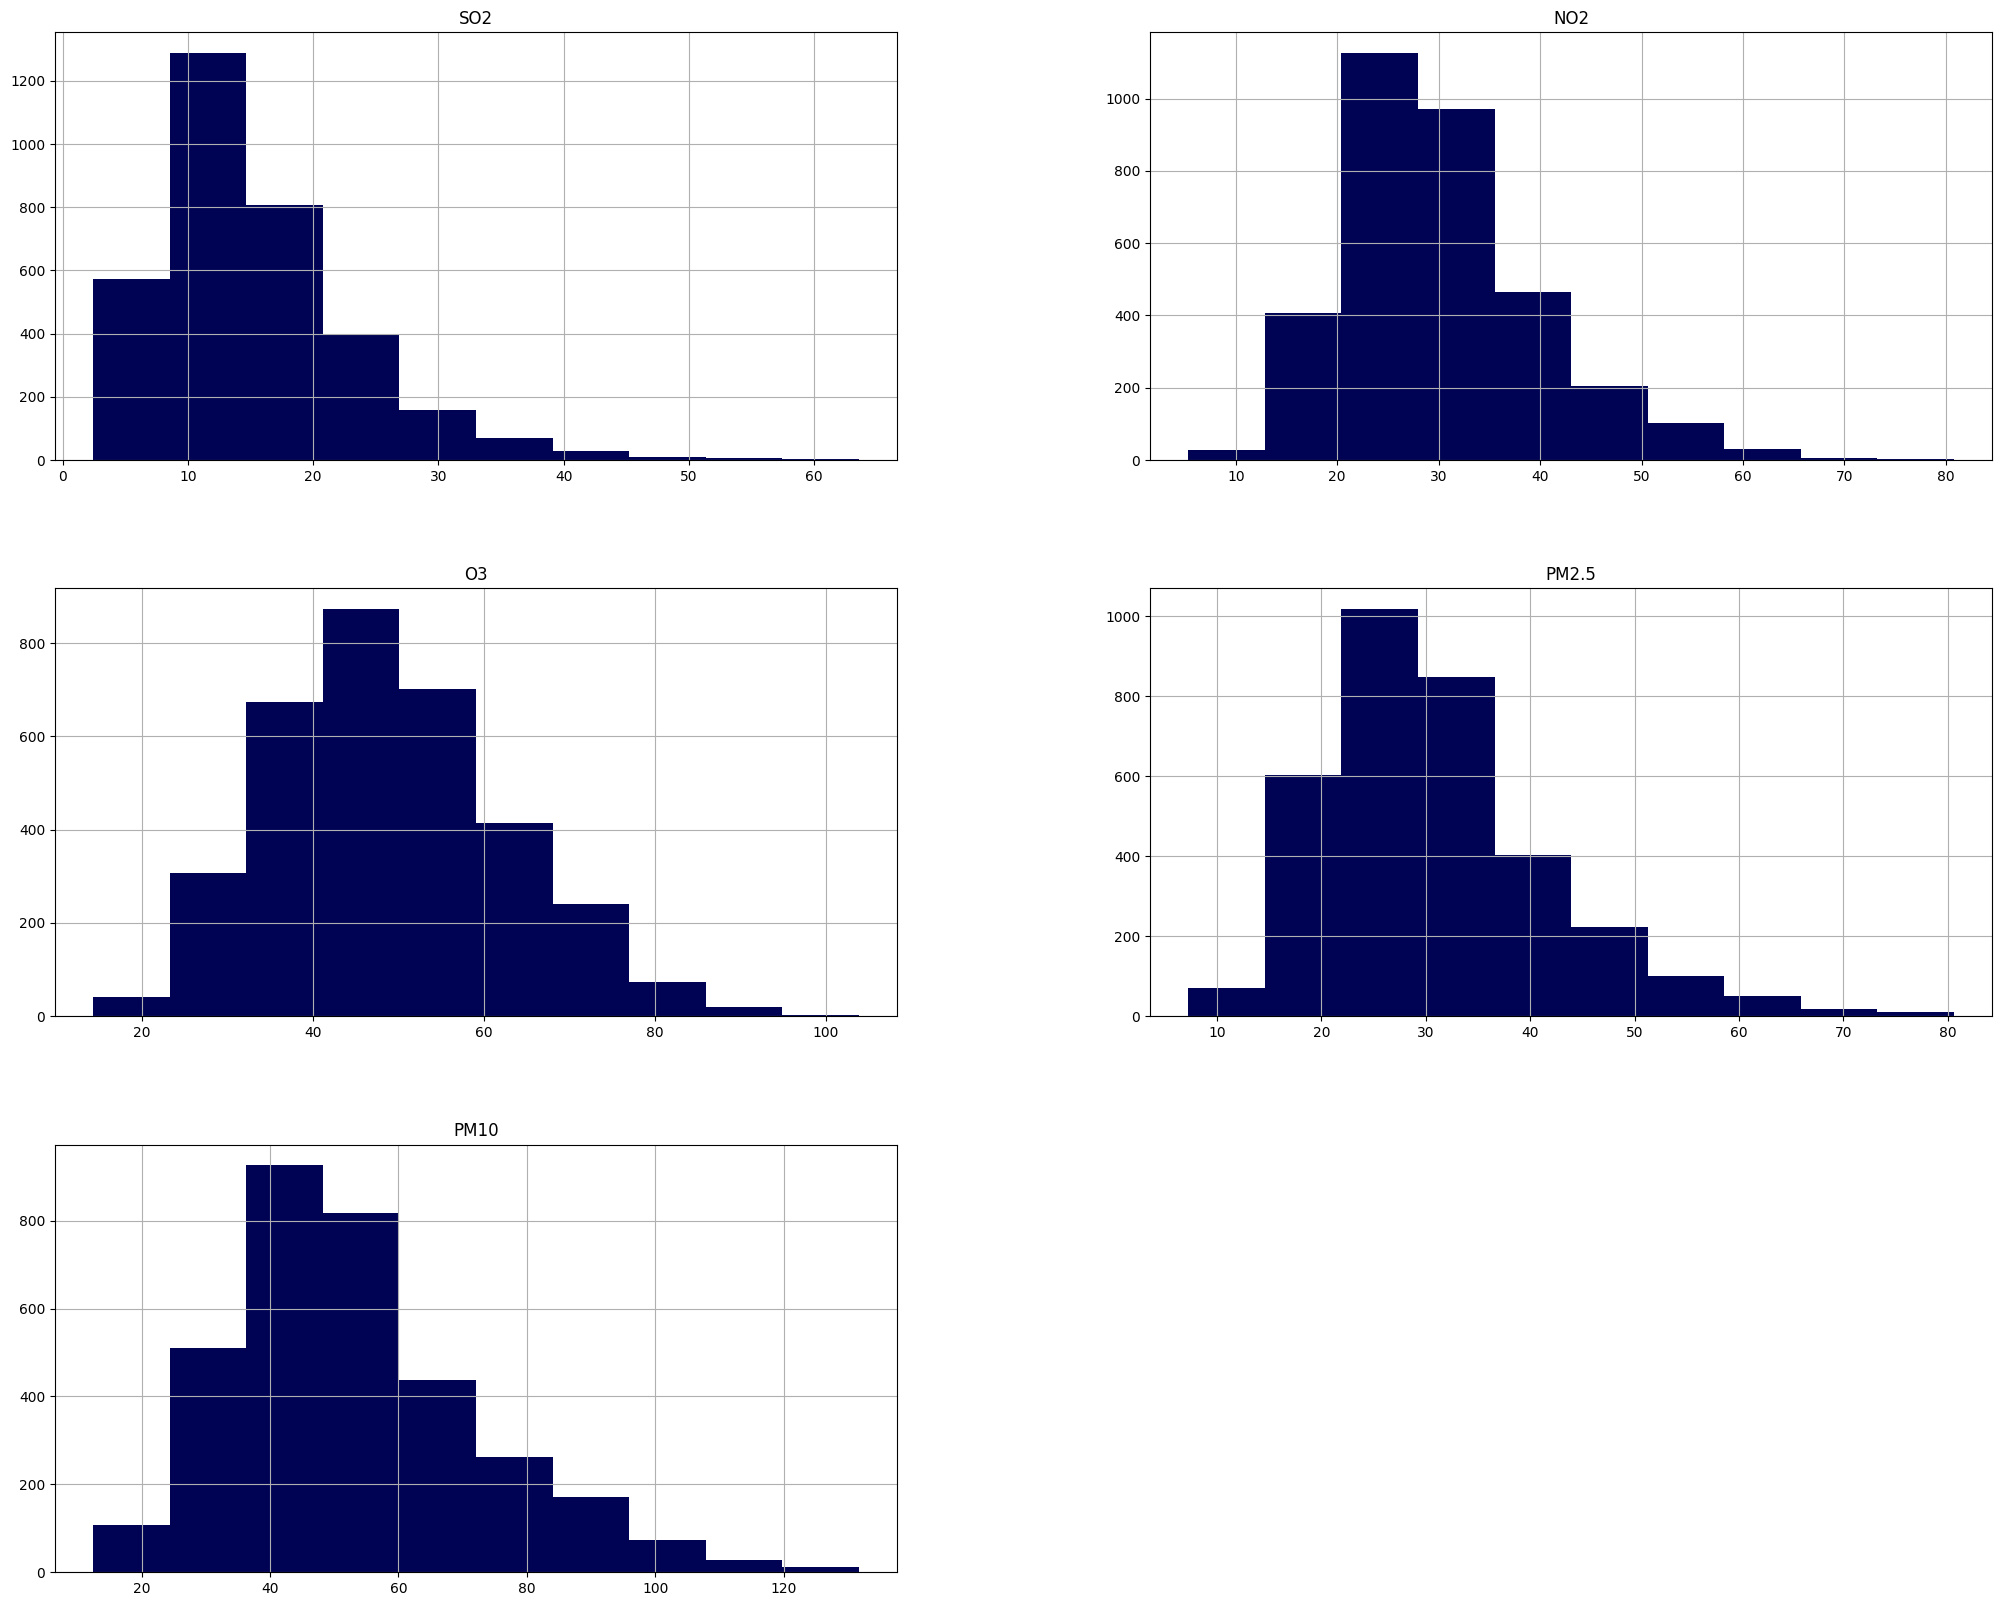

In [14]:
df_1 = df.copy()
features = df_1.columns

df_1[features].hist(figsize = (25,20),  color = '#000354');

###**Key Take Aways**

- Age and Na_to_K ratio are the most important features for distinguishing drug types.
- DrugY is the most prescribed drug, strongly associated with high Na_to_K values and high blood pressure.
- Gender is not a strong predictor due to the balanced male–female distribution.
- Cholesterol and BP have moderate impact, but when combined with Age and Na_to_K, they enhance model performance.
- The dataset suffers from class imbalance (DrugY and DrugX dominate). This must be dealt with in feature engineering.
- Na_to_K is the “golden feature”: it is the strongest indicator for drug classification and should be central in any automated prescription system.

# **Model Evaluation**

In [15]:
features = ['SO2', 'NO2', 'O3', 'PM2.5', 'PM10']
df_1 = df.copy()
X = df_1[features]

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


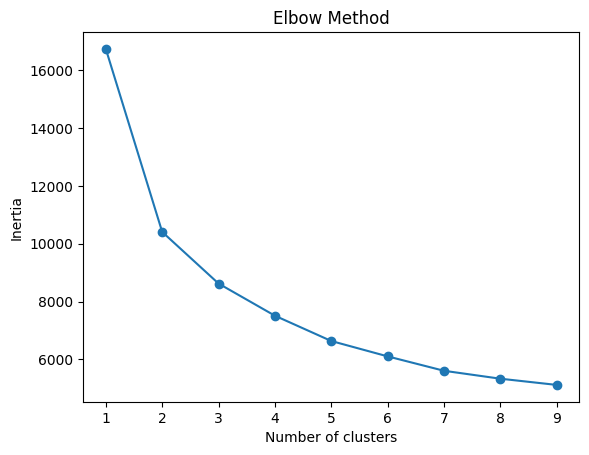

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [19]:
print(df.groupby('Cluster')[features].mean())

               SO2        NO2         O3      PM2.5       PM10
Cluster                                                       
0        23.649612  45.757274  39.388473  48.587289  83.963339
1        10.665348  23.392878  57.873649  22.974597  39.150989
2        16.750180  30.725804  44.746626  31.441867  54.312738


In [20]:
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f'k={k}, Silhouette Score={score:.3f}')


k=2, Silhouette Score=0.371
k=3, Silhouette Score=0.231
k=4, Silhouette Score=0.204
k=5, Silhouette Score=0.216
k=6, Silhouette Score=0.205
k=7, Silhouette Score=0.210
k=8, Silhouette Score=0.200
k=9, Silhouette Score=0.182


In [21]:
df['Cluster'] = kmeans.labels_

In [22]:
# Export to Excel
df.to_excel('clustered_airpollution.xlsx', index=False)
